Name: Vaishnavi Phalke

Rollno 47


Prn: 1252090032

8. Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing details of customers to predict customer response for special offer. Create confusion matrix based on above data and find Accuracy,Precision, Recall, F-1 score

Create CSV in Colab

In [ ]:
import pandas as pd

data_dict = {
"customer_id":[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
"age":[22,35,28,45,30,27,38,50,23,41,29,33,47,26,31,36,24,42,27,39],
"gender":["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
"income":[25000,55000,40000,75000,50000,30000,62000,85000,27000,68000,48000,52000,72000,32000,54000,60000,29000,70000,37000,65000],
"product_category":["Skincare","Makeup","Haircare","Fragrance","Skincare","Makeup","Haircare","Fragrance","Skincare","Makeup","Haircare","Skincare","Fragrance","Makeup","Haircare","Skincare","Makeup","Fragrance","Skincare","Haircare"],
"brand":["Lakme","Maybelline","LOreal","Chanel","Nivea","Colorbar","Dove","Gucci","Ponds","Revlon","Tresemme","Garnier","Dior","Nykaa","Head&Shoulders","Olay","SwissBeauty","Armani","Plum","LOreal"],
"price":[499,899,699,2999,399,799,499,4999,199,999,599,349,3999,699,449,799,399,4599,549,899],
"visit_frequency":[5,2,4,1,6,3,4,1,7,2,5,4,1,3,5,3,6,1,4,2],
"previous_purchases":[2,1,3,0,4,2,3,1,5,1,3,2,0,2,3,1,4,0,2,1],
"purchase":[1,0,1,0,1,0,1,0,1,0,1,1,0,1,1,0,1,0,1,0]
}

df = pd.DataFrame(data_dict)
df.to_csv("cosmetics.csv", index=False)

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.datasets import make_classification

Load Dataset

In [ ]:
df = pd.read_csv("cosmetics.csv")
print(df.head())
print(df.info())

   customer_id  age  gender  income product_category       brand  price  \
0            1   22  Female   25000         Skincare       Lakme    499   
1            2   35    Male   55000           Makeup  Maybelline    899   
2            3   28  Female   40000         Haircare      LOreal    699   
3            4   45    Male   75000        Fragrance      Chanel   2999   
4            5   30  Female   50000         Skincare       Nivea    399   

   visit_frequency  previous_purchases  purchase  
0                5                   2         1  
1                2                   1         0  
2                4                   3         1  
3                1                   0         0  
4                6                   4         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         20 non-null     int

Data Preprocessing

In [ ]:
le_gender = LabelEncoder()
le_category = LabelEncoder()
le_brand = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['product_category'] = le_category.fit_transform(df['product_category'])
df['brand'] = le_brand.fit_transform(df['brand'])

print(df.head())

   customer_id  age  gender  income  product_category  brand  price  \
0            1   22       0   25000                 3      9    499   
1            2   35       1   55000                 2     10    899   
2            3   28       0   40000                 1      8    699   
3            4   45       1   75000                 0      1   2999   
4            5   30       0   50000                 3     11    399   

   visit_frequency  previous_purchases  purchase  
0                5                   2         1  
1                2                   1         0  
2                4                   3         1  
3                1                   0         0  
4                6                   4         1  


Train Test Split

In [ ]:
X = df.drop(['customer_id','purchase'], axis=1)
y = df['purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Normalization

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression Model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Confusion Matrix (Binary)

Confusion Matrix:
 [[3 0]
 [0 1]]


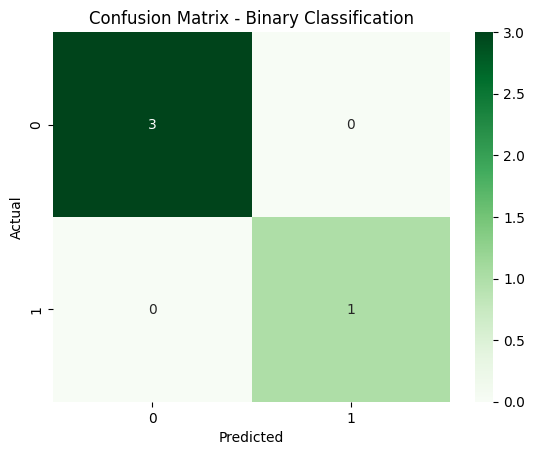

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy, Precision, Recall, F1-score

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Sigmoid Function Graph

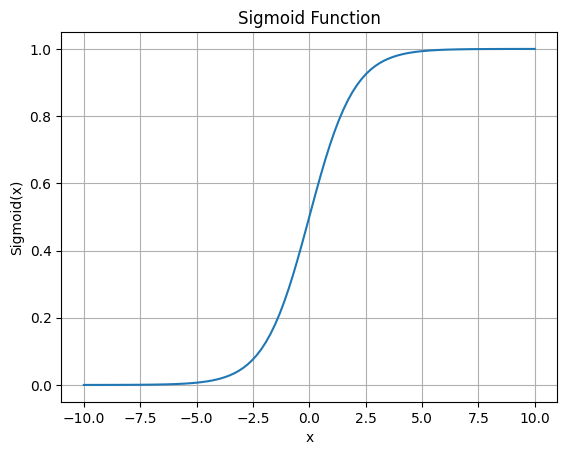

In [ ]:
x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure()
plt.plot(x, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid()
plt.show()

Synthetic Multiclass Data

In [ ]:
X_multi, y_multi = make_classification(
    n_samples=200,
    n_features=6,
    n_classes=3,
    n_informative=4,
    random_state=42
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

scaler_m = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m)
X_test_m = scaler_m.transform(X_test_m)

multi_model = LogisticRegression(multi_class='multinomial', max_iter=200)
multi_model.fit(X_train_m, y_train_m)

y_pred_m = multi_model.predict(X_test_m)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multiclass Confusion Matrix

Multiclass Confusion Matrix:
 [[14  2  5]
 [ 0  8  0]
 [ 1  2  8]]


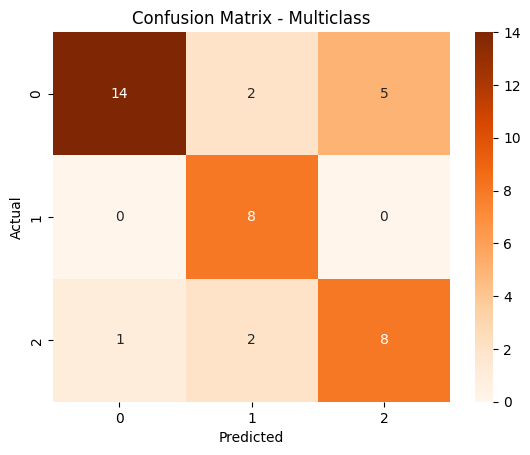


Multiclass Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.67      0.78        21
           1       0.67      1.00      0.80         8
           2       0.62      0.73      0.67        11

    accuracy                           0.75        40
   macro avg       0.74      0.80      0.75        40
weighted avg       0.79      0.75      0.75        40



In [ ]:
cm_multi = confusion_matrix(y_test_m, y_pred_m)

print("Multiclass Confusion Matrix:\n", cm_multi)

plt.figure()
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Multiclass")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nMulticlass Classification Report:\n")
print(classification_report(y_test_m, y_pred_m))